# **Veriyi SQL ile alma (Getting the data with SQL)**

In [436]:
import sqlite3
import pandas as pd

In [437]:
con = sqlite3.connect("/content/drive/MyDrive/ONLINE RETAIL/online_retail.sqlite")

In [438]:
query = """
SELECT *
FROM retail
WHERE CustomerID IS NOT NULL
  AND Quantity > 0
  AND UnitPrice > 0;
"""
df = pd.read_sql(query,con=con)
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00.000000,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00.000000,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00.000000,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00.000000,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00.000000,3.39,17850.0,United Kingdom


In [439]:
df["Revenue"] = df["UnitPrice"]*df["Quantity"]

In [440]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
df["Week"] = df["InvoiceDate"].dt.isocalendar().week

# **Aykırı Değerleri tespit edip yok etme (Finding outliers and dropping them)**

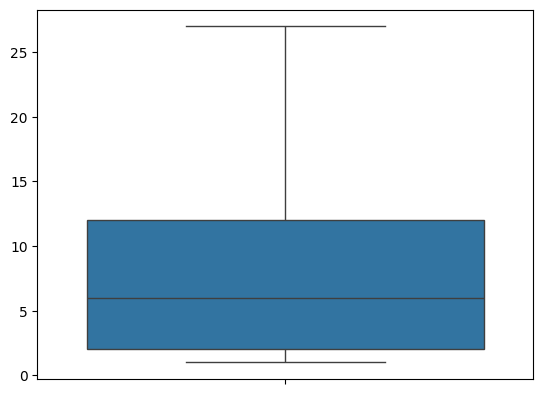

In [441]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(np.array(df["Quantity"]),showfliers=False)
plt.show()

In [442]:
def outlier_thresholds(dataframe, variable,limit):
  Q1 = dataframe[variable].quantile(limit)
  Q3 = dataframe[variable].quantile(1-limit)
  IQR = Q3-Q1
  low_limit = Q1-(1.5*IQR)
  up_limit = Q3+(1.5*IQR)
  return low_limit, up_limit
low_limit, up_limit = outlier_thresholds(df,"Quantity",0.25)
df = df[(df["Quantity"]>low_limit) & (df["Quantity"]<up_limit)]

# **Müşteri Analizi (Customer Analysis)**

In [521]:
df_cust = df.groupby("CustomerID")

# Müşteri kaç kez alışveriş yaptı? (How many times customer came to shopping?)
df_cust_inv =df_cust["InvoiceNo"].nunique()

# Müşteri ne kadar harcadı? (How much customer spend?)
df_cust_monetary = df_cust["Revenue"].sum()

# Müşteri kaç ürün aldı? (How many product customer bought?)
df_cust_freq = df_cust["InvoiceNo"].count()

# Müşteri en son kaç gün önce geldi? (How many days ago last shopping of customer?)
df_cust_recency = df_cust["InvoiceDate"].max()
df_cust_recency = (df["InvoiceDate"].max()-df_cust_recency).dt.days
indexes = np.array(df_cust["InvoiceDate"].nunique().index)

In [522]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_cust_monetary = scaler.fit_transform(df_cust_monetary.values.reshape(-1,1))
df_cust_inv = scaler.fit_transform(df_cust_inv.values.reshape(-1,1))
df_cust_freq = scaler.fit_transform(df_cust_freq.values.reshape(-1,1))
df_cust_recency = scaler.fit_transform(df_cust_recency.values.reshape(-1,1))

In [523]:
df_rfm = pd.DataFrame({"CustomerID":indexes,"Recency":df_cust_recency.T[0], "Frequency": df_cust_inv.T[0],"Monetary":df_cust_monetary.T[0]})

cols = ["Recency", "Frequency", "Monetary"]

for col in cols:
    low, up = outlier_thresholds(df_rfm, col,0.05)
    df_rfm = df_rfm[(df_rfm[col] > low) & (df_rfm[col] < up)]
print("All clear")

All clear


In [524]:
df_rfm_np = np.array((df_rfm["Recency"],df_rfm["Frequency"],df_rfm["Monetary"])).T

In [525]:
k = 3

clusters = {}
np.random.seed(23)

for idx in range(k):
    center = 2*(2*np.random.random((3,))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : [],
        'customer_ids': []
    }
    clusters[idx] = cluster

clusters

{0: {'center': array([0.06919154, 1.78785042, 1.06183904]),
  'points': [],
  'customer_ids': []},
 1: {'center': array([-0.87041662, -1.11581855,  0.74488834]),
  'points': [],
  'customer_ids': []},
 2: {'center': array([-1.33144319, -0.43023013,  0.47220939]),
  'points': [],
  'customer_ids': []}}

In [526]:
def euclidean_distance(point, center):
  return np.sqrt(np.sum((point-center)**2))

In [531]:
indexes = df_rfm["CustomerID"]
indexes = np.array(indexes)

In [552]:
cluster_array = []
for i in range(len(df_rfm_np)):
  min = np.inf
  for j in range(len(clusters)):
    result = euclidean_distance(df_rfm_np[i],clusters[j]["center"])
    if result<min:
      min = result
      cluster_idx = j
  clusters[cluster_idx]["points"].append(df_rfm_np[i])
  clusters[cluster_idx]["center"] = np.mean(clusters[cluster_idx]["points"],axis=0)
  clusters[cluster_idx]["customer_ids"].append(indexes[i])
  cluster_array.append(cluster_idx)
print(clusters)

{0: {'center': array([-0.75434163,  1.10612392,  0.93381529]), 'points': [array([-0.73624007,  1.10033152,  0.41723447]), array([-0.67619378,  1.10033152,  2.41750158]), array([-0.89636351,  0.68327884,  0.7810718 ]), array([-0.66618606,  0.68327884,  2.18500972]), array([-0.32592375,  1.23934908,  1.22068164]), array([-0.91637894,  0.40524373,  2.4851998 ]), array([-0.90637122,  1.93443687,  1.08160752]), array([-0.71622464,  0.12720861,  1.29406573]), array([-0.81630179,  0.12720861,  1.90630846]), array([-0.60613977,  0.40524373,  1.67084405]), array([-0.90637122,  0.40524373,  0.82333739]), array([-0.34593918, -0.01180895,  1.76660527]), array([-0.89636351,  0.8222964 ,  1.34706363]), array([-0.73624007,  1.10033152,  0.41723447]), array([-0.67619378,  1.10033152,  2.41750158]), array([-0.89636351,  0.68327884,  0.7810718 ]), array([-0.66618606,  0.68327884,  2.18500972]), array([-0.32592375,  1.23934908,  1.22068164]), array([-0.91637894,  0.40524373,  2.4851998 ]), array([-0.9063

In [553]:
df_rfm["Clusters"]  = np.array(cluster_array)
df_rfm

,CustomerID,Recency,Frequency,Monetary,Clusters
0,12347.0,-0.906371,0.405244,0.823337,0
1,12348.0,-0.175808,-0.011809,-0.280442,1
2,12349.0,-0.736240,-0.428862,0.140331,1
3,12350.0,2.176005,-0.428862,-0.320467,2
4,12352.0,-0.566109,0.544261,0.430151,0
...,...,...,...,...,...
4233,18280.0,1.855758,-0.428862,-0.373628,2
4234,18281.0,0.885010,-0.428862,-0.408116,2
4235,18282.0,-0.846325,-0.289844,-0.379321,1
4236,18283.0,-0.886356,1.656402,0.288035,0


In [533]:
print(f"Centroid1: {clusters[0]['center']}")
print(f"Centroid2: {clusters[1]['center']}")
print(f"Centroid3: {clusters[2]['center']}")
centers = np.array((clusters[0]["center"],clusters[1]["center"],clusters[2]["center"])).T

Centroid1: [-0.75476963  1.12006109  0.95958088]
Centroid2: [-0.4646344  -0.15695889 -0.14299389]
Centroid3: [ 1.54095568 -0.35168691 -0.29401334]


In [534]:
centers

array([[-0.75476963, -0.4646344 ,  1.54095568],
       [ 1.12006109, -0.15695889, -0.35168691],
       [ 0.95958088, -0.14299389, -0.29401334]])

In [535]:
import plotly.express as px

# İnteraktif 3D Grafik (Interactive 3D Graphic)
fig = px.scatter_3d(df_rfm,
                    x='Recency',
                    y='Frequency',
                    z='Monetary',

                    title='K-Means Cluster Dağılımı ve Merkezleri',
                    opacity=0.1)

fig.add_scatter3d(x=centers[0], y=centers[1], z=centers[2],
                  mode='markers',
                  marker=dict(size=5, color='black', symbol='x'),
                  name='Centroids')

fig.show()

**Customer Analysis Result**

For Recency: Centroid1<Centroid2<Centroid3

For Monetary: Centroid3<Centroid2<Centroid1

For Frequency: Centroid3<Centroid2<Centroid1

So, we can group them as "Loyal, Potential and Lose"

So, point on **Centroid1 is Loyal, point on Centroid2 is Potential, point on Centroid3 is Lose**.


In [559]:
# CSV dosyası
"""
unscaled_data = scaler.inverse_transform(df_rfm_np)
df_original = pd.DataFrame(unscaled_data, columns=['Recency', 'Frequency', 'Monetary'])
df_original["CustomerID"] = df_rfm["CustomerID"]
df_original["Clusters"] = df_rfm["Clusters"]
df_original.to_csv('customer_segments.csv', index=False)

"""


# **Analizler (Analysis)**

In [536]:
df_hour_sale = df.groupby("Hour")["Revenue"].sum()
df_day_sale = df.groupby("Day")["Revenue"].sum()
df_month_sale = df.groupby("Month")["Revenue"].sum()
df_year_sale = df.groupby("Year")["Revenue"].sum()

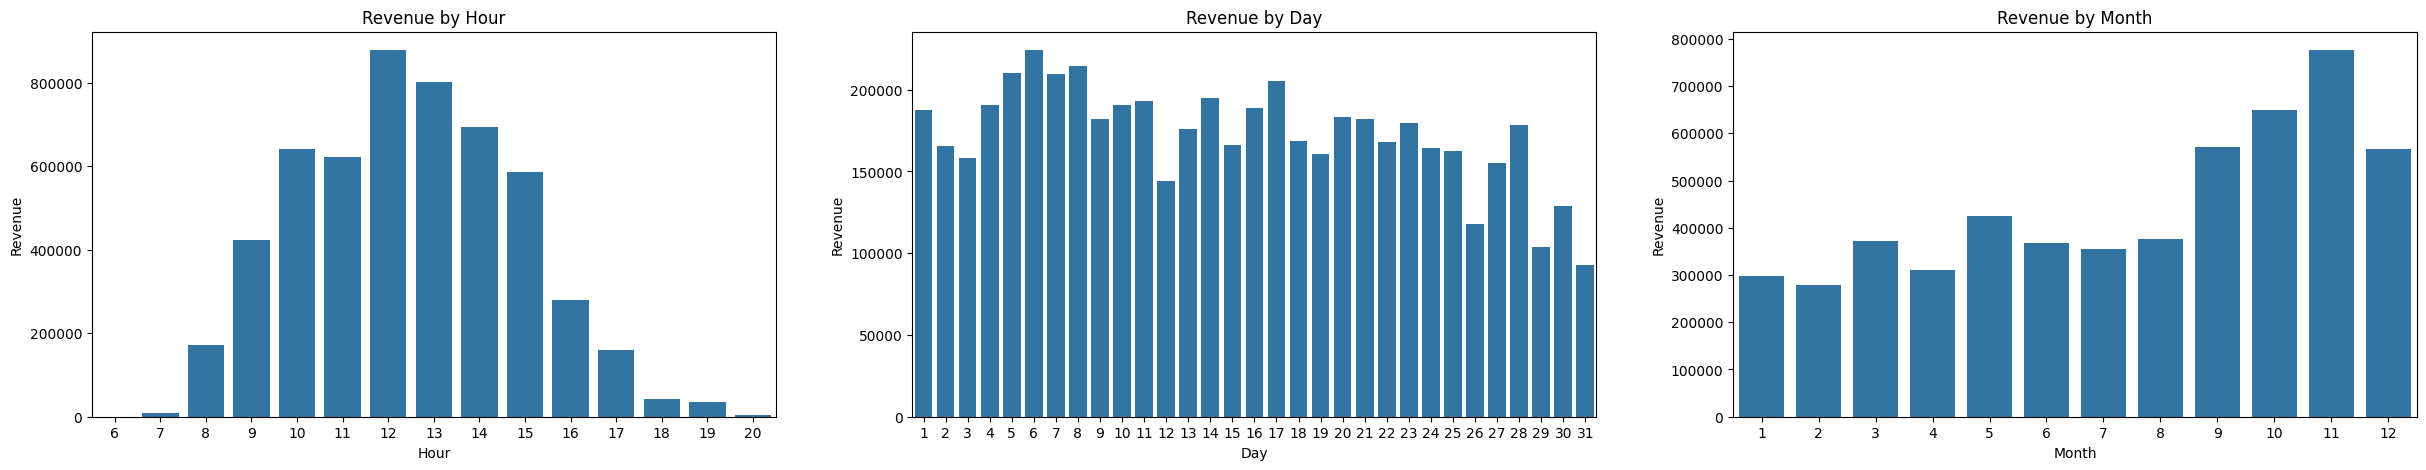

In [537]:
fig, axes = plt.subplots(1, 3, figsize=(30, 5))
sns.barplot(ax=axes[0],x=df_hour_sale.index,y=df_hour_sale.values)
axes[0].set_title("Revenue by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Revenue")
sns.barplot(ax=axes[1],x=df_day_sale.index,y=df_day_sale.values)
axes[1].set_title("Revenue by Day")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Revenue")
sns.barplot(ax=axes[2],x=df_month_sale.index,y=df_month_sale.values)
axes[2].set_title("Revenue by Month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Revenue")
plt.show()

In [538]:
df=df.drop(["index","Description"],axis=1)

KeyError: "['index', 'Description'] not found in axis"

In [539]:
country_data = df.groupby('Country')['Revenue'].sum().reset_index()
country_data = country_data.sort_values(by='Revenue', ascending=False)
country_data_without_uk = df[df["Country"]!="United Kingdom"]
country_data_without_uk = country_data_without_uk.groupby('Country')['Revenue'].sum().reset_index()
country_data_without_uk = country_data_without_uk.sort_values(by='Revenue', ascending=False)
country_data.head()

,Country,Revenue
35,United Kingdom,4470830.664
14,Germany,185419.520
13,France,168341.530
10,EIRE,145090.630
30,Spain,43928.710


In [540]:
import plotly.express as px

fig = px.pie(country_data,
             values='Revenue',
             names='Country',
             title='Country Based Revenue',
             hover_data=['Revenue'],
             hole=0.37)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig1 = px.pie(country_data_without_uk,
             values='Revenue',
             names='Country',
             title='Country Based Revenue Without UK',
             hover_data=['Revenue'],
             hole=0.37)

fig1.update_traces(textposition='inside', textinfo='percent+label')

print(fig.show())
print(fig1.show())

None


None


# **Time Series**

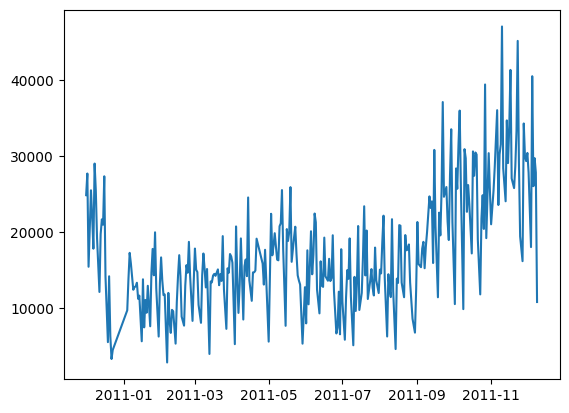

<Figure size 2000x500 with 0 Axes>

In [541]:
df["Date"] = df["InvoiceDate"].dt.date
df_date = df.groupby("Date",as_index=False)["Revenue"].sum()
df_date.rename(columns={'Date': 'ds', 'Revenue': 'y'}, inplace=True)
plt.plot(df_date['ds'],df_date['y'])
plt.figure(figsize=(20,5))
plt.show()

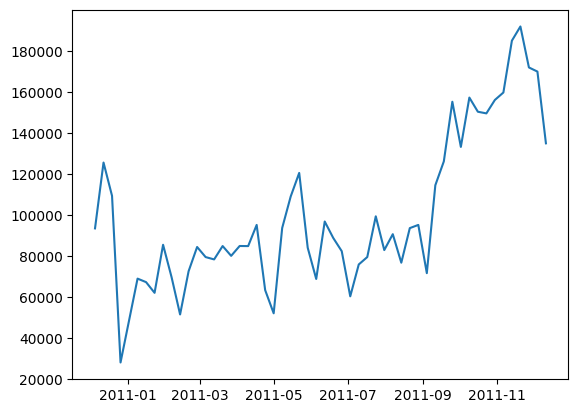

<Figure size 2000x500 with 0 Axes>

In [542]:
df_date['ds'] = pd.to_datetime(df_date['ds'])
df_weekly = df_date.set_index('ds').resample('W').sum().reset_index()
df_weekly['y'] = df_weekly['y'].replace(0, np.nan).interpolate()

plt.plot(df_weekly['ds'],df_weekly['y'])
plt.figure(figsize=(20,5))
plt.show()

In [543]:
period = 25
train_period = 305-period
train = df_date[0:train_period]
test = df_date[train_period:305]
train_week = df_weekly[:-4]
test_week = df_weekly[-4:]

In [544]:
from prophet import Prophet
# Model for daily
m = Prophet()
m.fit(train)
future = m.make_future_dataframe(periods=period)
forecast = m.predict(future)
# Model for weekly
model_weekly = Prophet(daily_seasonality=False,weekly_seasonality=True,yearly_seasonality=False)
model_weekly.fit(train_week)
future_weekly = model_weekly.make_future_dataframe(periods=4,freq="W")
forecast_weekly = model_weekly.predict(future_weekly)


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


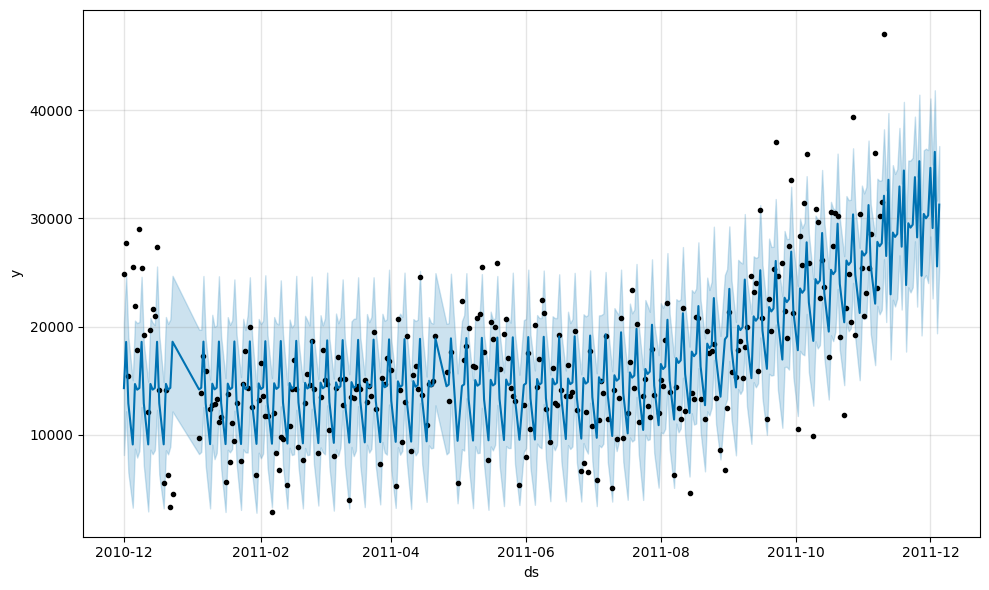

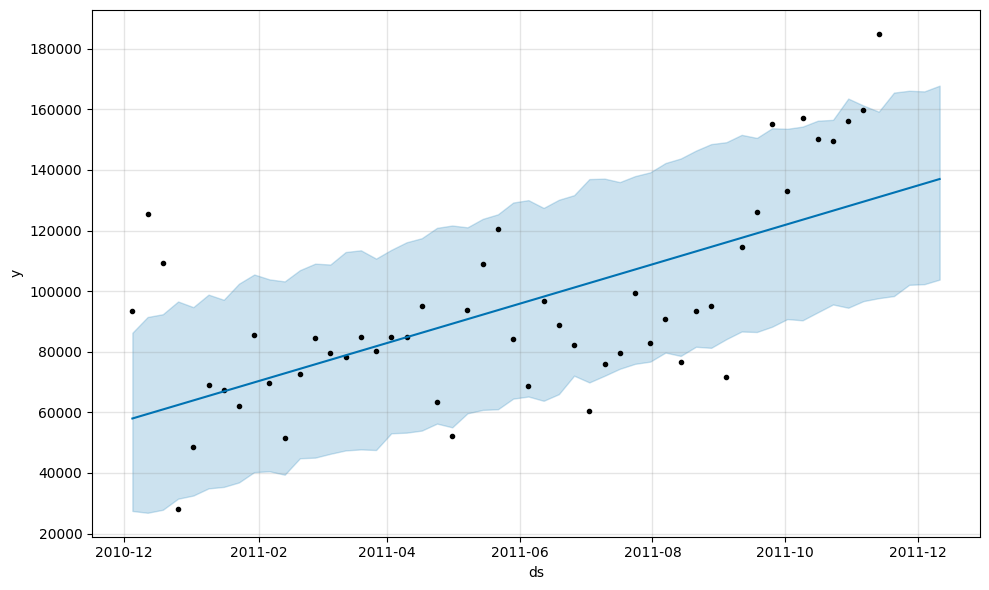

In [545]:
fig1 = m.plot(forecast)
fig1.show()
fig1_weekly = model_weekly.plot(forecast_weekly)
fig1_weekly.show()

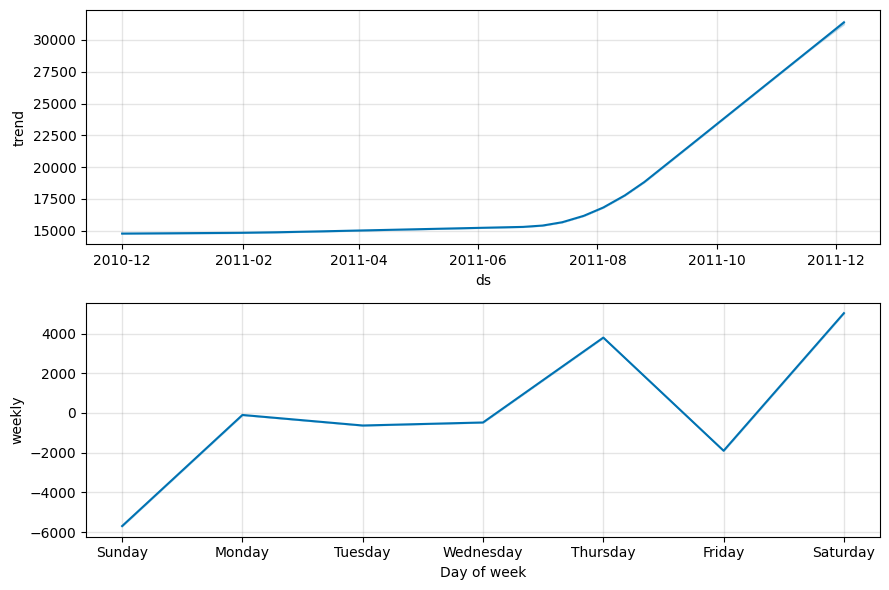

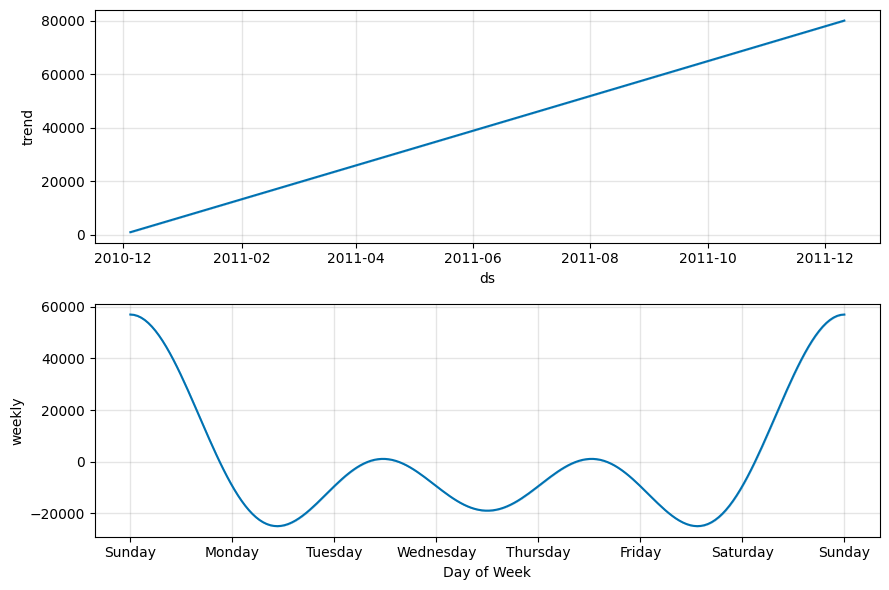

In [546]:
fig2 = m.plot_components(forecast)
fig2.show()
fig2_weekly = model_weekly.plot_components(forecast_weekly)
fig2_weekly.show()

In [547]:
from sklearn.metrics import root_mean_squared_error
rmse_daily = root_mean_squared_error(df_date["y"][train_period:305],forecast["yhat"][train_period:305])
mean_daily = df_date.y[train_period:305].mean()
rmse_weekly = root_mean_squared_error(df_weekly["y"][-4:],forecast_weekly["yhat"][-4:])
mean_weekly = df_weekly.y[-4:].mean()
print(f"RMSE for Daily: {rmse_daily}")
print(f"Error Rate for Daily: {(rmse_daily / mean_daily) * 100}%")
print(f"RMSE for Weekly: {rmse_weekly}")
print(f"Error Rate for Weekly: {(rmse_weekly / mean_weekly) * 100}%")

RMSE for Daily: 8935.803537212792
Error Rate for Daily: 30.992906565267386%
RMSE for Weekly: 39135.21435309607
Error Rate for Weekly: 23.42260524173971%


In [555]:
# CSV file
"""
forecast_weekly[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('sales_forecast.csv', index=False)

"""

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


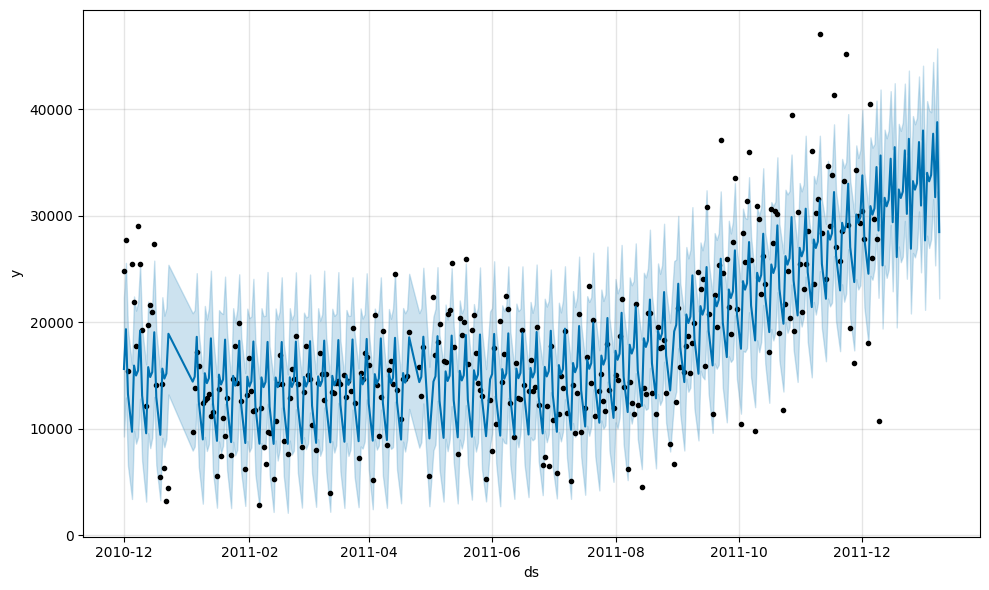

In [548]:
model_future = Prophet()
model_future.fit(df_date)
period = 30
future_future = model_future.make_future_dataframe(periods=period,freq="D")
forecast_future = model_future.predict(future_future)
fig3 = model_future.plot(forecast_future)
fig3.show()

In [549]:
predictions = forecast_future[305:305+period]["yhat"]